In [120]:
import torch
from torchvision import datasets, transforms

In [121]:
# Resize:
# 원래 28x28 이미지를 32x32로 확대한다.
#
# ToTensor:
# 이미지를 (channel, height, width) tensor로 변환하고
# 픽셀값을 [0, 1] 범위의 float로 바꾼다.
transform = transforms.Compose([
    transforms.Resize((32, 32)), # 32 x 32
    transforms.ToTensor(),
])

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True,
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    transform=transform,
    download=True,
)

In [122]:
print("Number of training examples:", len(train_dataset))
print("Number of test examples:", len(test_dataset))

assert len(train_dataset) == 60_000
assert len(test_dataset) == 10_000

Number of training examples: 60000
Number of test examples: 10000


In [123]:
# 데이터 하나는 (image, label) 형태로 반환된다.
image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Label:", label)
print("Pixel dtype:", image.dtype)
print("Minimum pixel value:", image.min().item())
print("Maximum pixel value:", image.max().item())

assert image.shape == (1, 32, 32)
assert 0 <= image.min() <= image.max() <= 1

Image shape: torch.Size([1, 32, 32])
Label: 9
Pixel dtype: torch.float32
Minimum pixel value: 0.0
Maximum pixel value: 0.9529411792755127


In [124]:
label_names = [
    "t-shirt",
    "trouser",
    "pullover",
    "dress",
    "coat",
    "sandal",
    "shirt",
    "sneaker",
    "bag",
    "ankle boot",
]

def text_label(label):
    return  label_names[int(label)]

print("Numeric label:", label)
print("Text label:", text_label(label))

Numeric label: 9
Text label: ankle boot


In [125]:
from torch.utils.data import DataLoader

batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

print("Number of training batches:", len(train_loader))
print("Number of test batches:", len(test_loader))


Number of training batches: 938
Number of test batches: 157


In [ ]:
batch_images, batch_labels = next(
    iter(train_loader)
)

# 이미지의 shape: [B, C, H, W]
print("Image batch shape:", batch_images.shape)
print("Image batch dtype:", batch_images.dtype)

print("\nLabel batch shape:", batch_labels.shape)
print("Label batch dtype:", batch_labels.dtype)

# 미니배치에서 첫 번째 이미지와 레이블을 확인한다.
first_image = batch_images[0]
first_label = batch_labels[0]

print("\nSingle image shape:", first_image.shape)
print("Numeric label:", first_label.item())
print("Text label:", text_label(first_label))

Image batch shape: torch.Size([64, 1, 32, 32])
Image batch dtype: torch.float32

Label batch shape: torch.Size([64])
Label batch dtype: torch.int64

Single image shape: torch.Size([1, 32, 32])
Numeric label: 3
Text label: dress


In [ ]:
import time 

start_time = time.perf_counter()

# 학습 데이터 전체를 미니배치 단위로 한 번 읽는다.
for batch_images, batch_labels in train_loader:
    pass

elapsed_time = time.perf_counter() - start_time

print(f"Time to read training dataset: {elapsed_time:.2f} sec")

In [128]:
import matplotlib.pyplot as plt


def show_images(
    images,
    labels,
    num_rows=1,
    num_cols=8,
    scale=1.5,
):
    """미니배치의 이미지와 레이블을 격자로 표시한다."""

    figure, axes = plt.subplots(
        num_rows,
        num_cols,
        figsize=(
            num_cols * scale,
            num_rows * scale,
        ),
        squeeze=False,
    )

    for axis, image, label in zip(
        axes.flat,
        images,
        labels,
    ):
        # 회색조 이미지:
        # (1, height, width) -> (height, width)
        if image.shape[0] == 1:
            image = image.squeeze(0)

        # RGB 이미지라면:
        # (channels, height, width)
        # -> (height, width, channels)
        else:
            image = image.permute(1, 2, 0)

        axis.imshow(
            image,
            cmap="gray",
        )
        axis.set_title(label)
        axis.axis("off")

    plt.tight_layout()

    return figure, axes

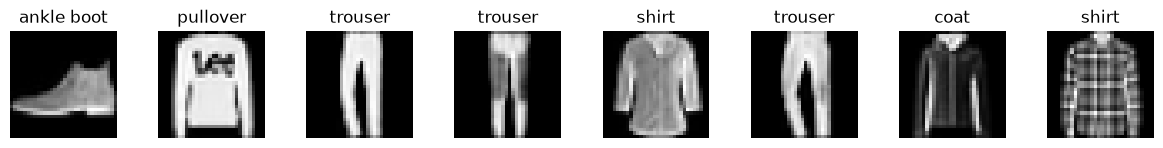

In [137]:
batch_images, batch_labels = next(
    iter(test_loader)
)

num_images = 8

images_to_show = batch_images[:num_images]

labels_to_show = [
    text_label(label)
    for label in batch_labels[:num_images]
]

show_images(
    images=images_to_show,
    labels=labels_to_show,
    num_rows=1,
    num_cols=num_images,
)

plt.show()